In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

## After training (V1)

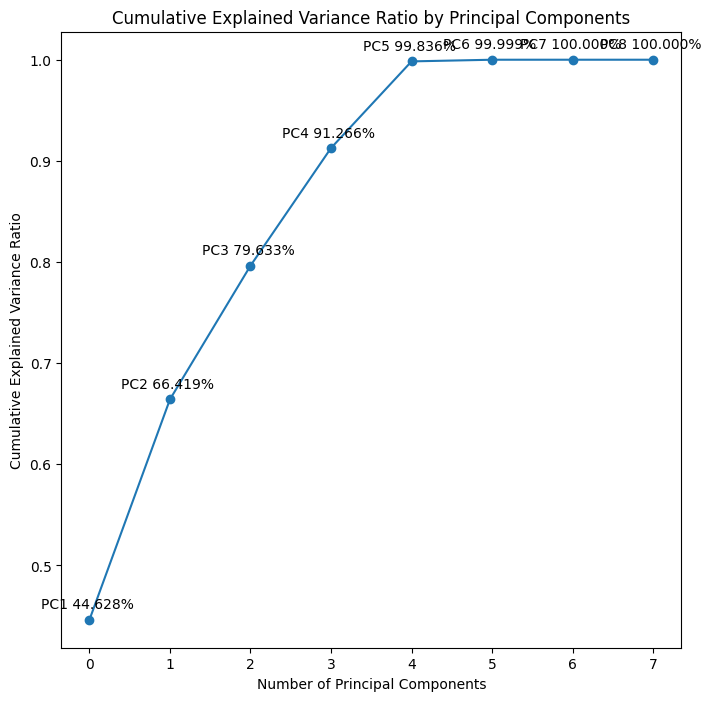

In [4]:
import os
from utils.explained_variance_ratio import explained_variance
from script.shell import MinimalTransformer # this dimension and all the params should match the file saved in .pth
vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)

checkpoint_dir = os.path.join(PROJECT_ROOT, 'checkpoints')
file_name = 'v1.pth'
full_path = os.path.join(checkpoint_dir, file_name)


explained_variance(full_path, model=model)

## V(2)


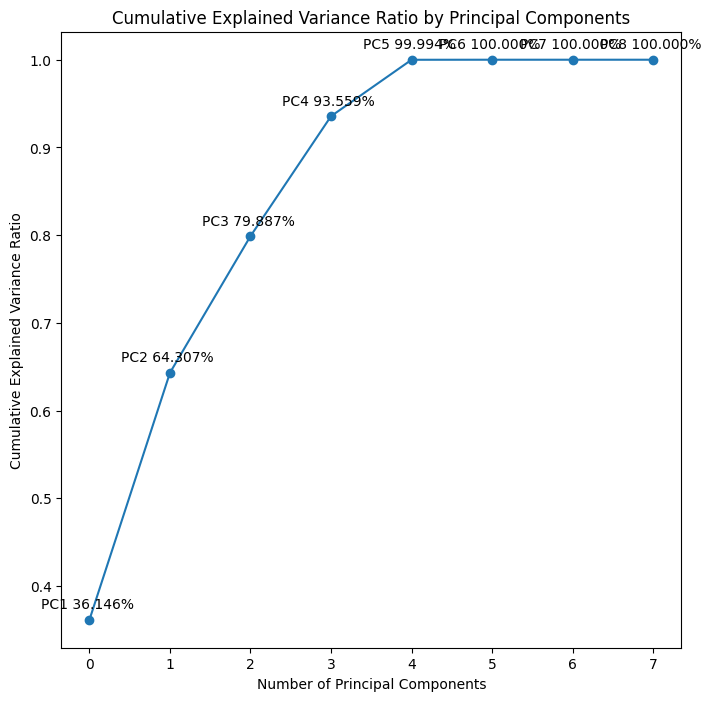

In [5]:
from script.shell import MinimalTransformer
vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)
explained_variance(os.path.join(checkpoint_dir, 'v2.pth'), model)

V(3)

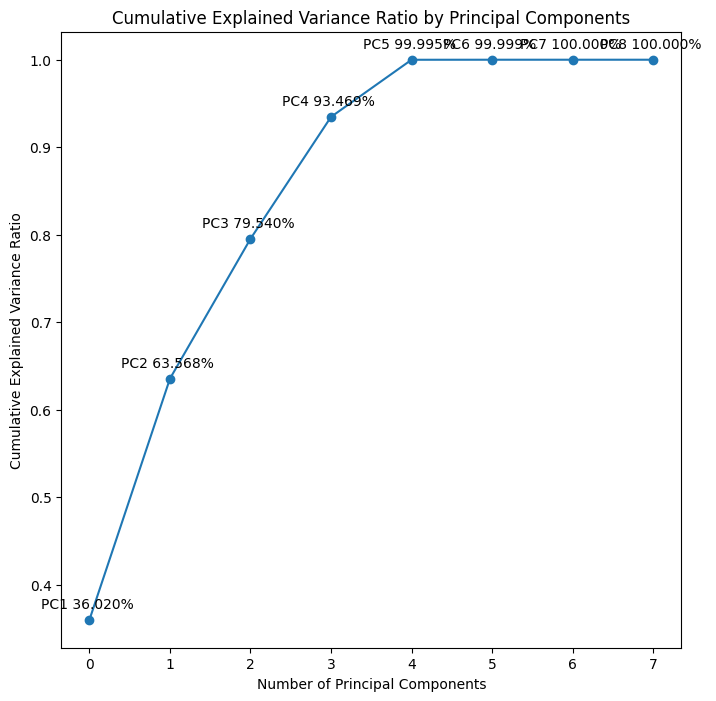

In [6]:
from script.shell import MinimalTransformer 
vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)

explained_variance(os.path.join(checkpoint_dir, 'v3.pth'), model)

## Before training

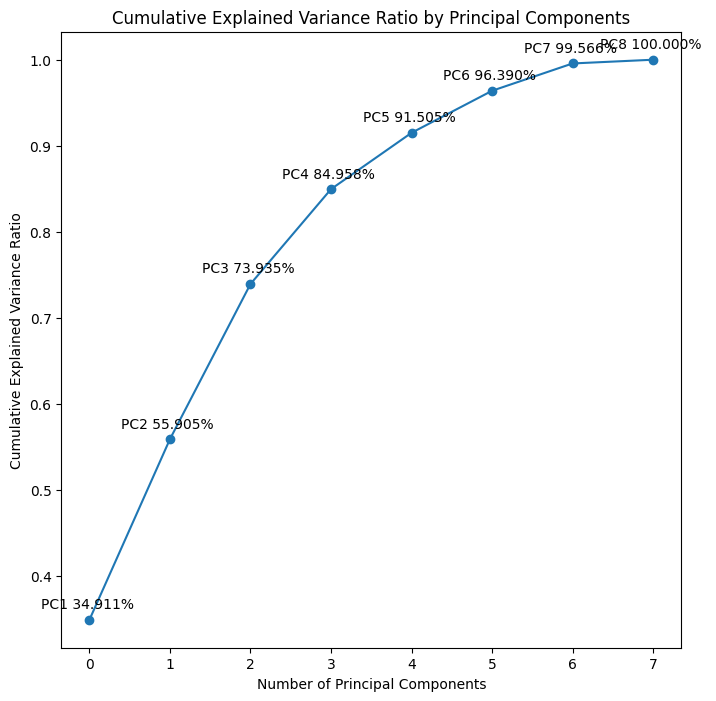

In [7]:
from script.shell import MinimalTransformer
file_name = 'v1_initial.pth'
full_path = os.path.join(checkpoint_dir, file_name)
vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)
explained_variance(full_path, model)

### Check with reducation in dimension, based on Explained PCA ratio we found that there is a reducation in dimension.

Epoch 1, Loss (Training): 2.3315 Loss(val): 2.1963
Epoch 2, Loss (Training): 2.1347 Loss(val): 2.0849
Epoch 3, Loss (Training): 2.0255 Loss(val): 1.9614
Epoch 4, Loss (Training): 1.8891 Loss(val): 1.8299
Epoch 5, Loss (Training): 1.7729 Loss(val): 1.7217
Epoch 6, Loss (Training): 1.6669 Loss(val): 1.6126
Epoch 7, Loss (Training): 1.5482 Loss(val): 1.4853
Epoch 8, Loss (Training): 1.4278 Loss(val): 1.3831
Epoch 9, Loss (Training): 1.3453 Loss(val): 1.3159
Epoch 10, Loss (Training): 1.2833 Loss(val): 1.2568
Epoch 11, Loss (Training): 1.2251 Loss(val): 1.1992
Epoch 12, Loss (Training): 1.1708 Loss(val): 1.1477
Epoch 13, Loss (Training): 1.1251 Loss(val): 1.1065
Epoch 14, Loss (Training): 1.0877 Loss(val): 1.0721
Epoch 15, Loss (Training): 1.0557 Loss(val): 1.0411
Epoch 16, Loss (Training): 1.0225 Loss(val): 1.0037
Epoch 17, Loss (Training): 0.9806 Loss(val): 0.9600
Epoch 18, Loss (Training): 0.9356 Loss(val): 0.9153
Epoch 19, Loss (Training): 0.8922 Loss(val): 0.8755
Epoch 20, Loss (Train

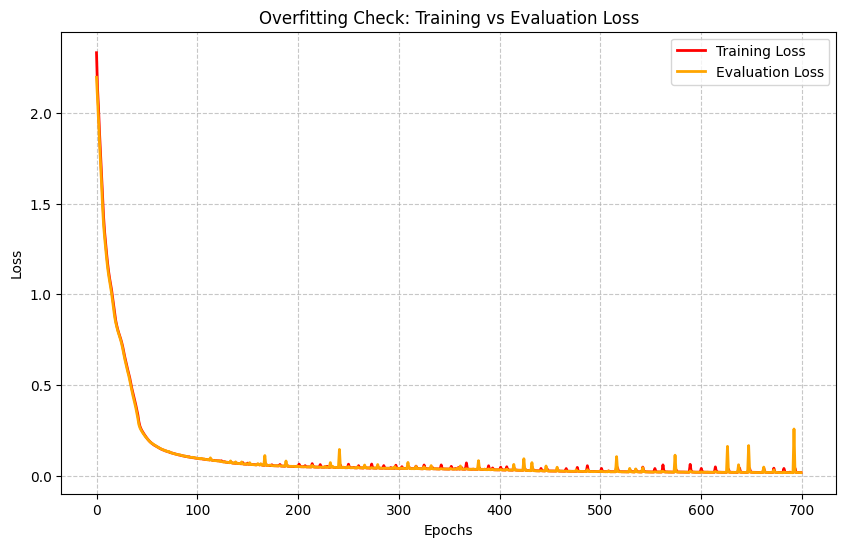

Successfully saved to: ../checkpoints/v_exp.pth


In [11]:
import time
import torch
import torch.nn as nn
from utils.explained_variance_ratio import overfitting_plot
from torch.utils.data import Dataset, DataLoader, random_split

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class FibonacciModDataset(Dataset):
    def __init__(self, seq_len=10, mod=10, num_samples=10000):
        self.mod = mod

        self.global_seq = self.generate_fib_sequence(1000, mod)
        self.samples = []
        for _ in range(num_samples):
            start_idx = torch.randint(0, len(self.global_seq) - seq_len - 1, (1,)).item()
            seq = self.global_seq[start_idx:start_idx + seq_len + 1]
            x = torch.tensor(seq[:-1], dtype=torch.long)
            y = torch.tensor(seq[1:], dtype=torch.long)
            self.samples.append((x, y))

    def generate_fib_sequence(self, length, mod):
        seq = [1, 1] # these are the starting values
        while len(seq) < length: # this prevents overlap
            seq.append((seq[-1] + seq[-2]) % mod)
        return seq

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

class MinimalTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=6, n_heads=3, num_layers=1, max_seq_len=20):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_seq_len, d_model)
        self.layers = nn.ModuleList([
            nn.MultiheadAttention(d_model, n_heads, batch_first=True)
            for _ in range(num_layers)
        ])
        self.out_proj = nn.Linear(d_model, vocab_size)

    def forward(self, tokens):
        B, T = tokens.shape
        pos = torch.arange(T, device=tokens.device)
        x = self.token_embed(tokens) + self.pos_embed(pos).unsqueeze(0)
        attn_mask = torch.triu(torch.ones(T, T, device=tokens.device) * float('-inf'), diagonal=1)
        for attn in self.layers:
            attn_out, _ = attn(x, x, x, attn_mask=attn_mask)
            x = x + attn_out
        return self.out_proj(x)
    
    def get_embeddings(self):
        return self.pos_embed + self.token_embed
    


train_plot = []
eval_plot = []
def train_model(model, dataloader, test_loader, epochs=12, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train() # because we have that eval mode after each epoch
        total_loss = 0
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            
            logits = model(x)
            loss = loss_fn(logits[:, 1:].reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        train_plot.append({'loss': avg_loss, 'epoch': epoch})  
        
        model.eval()
        with torch.no_grad():
            val_loss = evaluate_model(model, test_loader)
            eval_plot.append(val_loss)
    
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1}, Loss (Training): {avg_loss:.4f} Loss(val): {val_loss:.4f}")
    
    end_time = time.time()
    print(f"Total Training Time: {end_time - start_time:.2f} seconds")


def evaluate_model(model, dataloader, show_accuracy = False):
    correct, total = 0, 0
    loss_fn = nn.CrossEntropyLoss()
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            pred = logits.argmax(dim=-1)

            loss = loss_fn(logits[:, 1:].reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))
            total_loss += loss.item()

            correct += (pred[:, 1:] == y[:, 1:]).sum().item()
            total += y[:, 1:].numel()

    if show_accuracy:
      print(f"Accuracy (eval mode): {correct / total:.2%}")

    avg_loss = total_loss / len(dataloader) 
    return avg_loss

vocab_size = 10
batch_size = 128
generated_ds = FibonacciModDataset(num_samples=25000, mod=vocab_size, seq_len=20)



train_size = int(0.8 * len(generated_ds))
test_size = len(generated_ds) - train_size
train_ds, test_ds = random_split(generated_ds, [train_size, test_size]) 

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)
test_loader = DataLoader(test_ds, batch_size=batch_size, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)


model = MinimalTransformer(vocab_size=vocab_size).to(device)


checkpoint_dir = '../checkpoints' 
file_name = 'v_exp.pth'
full_path = os.path.join(checkpoint_dir, file_name)


try: 
    train_model(model, train_loader, epochs=700, test_loader=test_loader)
    evaluate_model(model, test_loader, show_accuracy=True)
except KeyboardInterrupt:
    pass    

overfitting_plot(train_plot, eval_plot)

if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

torch.save(model.state_dict(), full_path)
print(f"Successfully saved to: {full_path}")
